# Torricelli

Program computes the flow field for fluid exiting a tank assuming Torricelli's law.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Functions (boundary conditions)

In [2]:
# set boundary conditions
def SetzeRaender(u, Omega, g, dh, Nx, Ny, NL, Nu):
    u = u.copy()
    Omega = Omega.copy()

    # below the outlet  
    for i in range(NL, Nx + 2):      
        ix = i - 1                    
        u[ix, 0] = u[ix - 1, 1]       # du/dy = vx = 0
        Omega[ix - 1, 0] = Omega[ix - 1, 1]   # fluid at the bottom
        for j in range(1, Nu + 2):    
            if i == NL:
                vy = 0.0
            if i == Nx + 1:
                vy = -np.sqrt(2.0 * g * dh * (Ny + Nu - j))
            if i == Nx:
                vy = -0.5 * np.sqrt(2.0 * g * dh * (Ny + Nu - j))
            u[ix, j - 1] = u[ix - 1, j - 1] - vy * dh   # du/dx = -vy

    # right boundary
    for j in range(2, Ny + 2):        
        jy = j - 1
        vy = np.sqrt(2.0 * g * dh * (Ny + 1 - j))
        u[Nx, jy] = u[Nx - 1, jy] - vy * dh       # du/dx = -vy
        u[Nx, jy] = u[Nx, jy - 1]                 # du/dy = vx = 0
        Omega[Nx-1, jy] = -2*(u[Nx-1, jy] - u[Nx-1, jy-1]) / dh**2

    # bottom, left of the outlet
    for i in range(1, NL):            
        ix = i - 1
        u[ix, Nu - 1] = u[ix, Nu - 2]          # du/dy = vx = 0
        Omega[ix, Nu - 1] = -2.0 * (u[ix, 0] - u[ix, 1])

    # top boundary
    for i in range(1, Nx + 1):        
        ix = i - 1
        u[ix, Ny] = u[ix, Ny - 1]     # du/dy = vx = 0
        Omega[ix, Ny - 1] = 0.0

    # left boundary
    for j in range(Nu, Ny + 1):       
        jy = j - 1
        Omega[0, jy] = -2 * (u[0, jy] - u[1, jy]) / dh**2
        u[0, jy] = u[1, jy]

    Y = np.zeros((2, Nx + 1, Ny + 1))
    Y[0, :, :] = u[:, :]
    Y[1, :, :] = Omega[:, :]
    return Y

## Parameters

In [3]:
Nit = 4000                            # (maximum) number of iterations
s = 0.1                               # convergence parameter

dh = 4.0e-3                           # spacing between two grid points (in m)
Nx = 50                               # grid points in x-direction
Ny = 200                              # grid points in y-direction
NL = 40                               # grid point nx where the outlet opening begins
Nu = 20                               # grid points below the outlet

g = 9.81                              # gravitational acceleration (in m/s^2)
nu = 2.5e-3                           # kinematic viscosity

## Set up grid and compute boundary velocities

In [4]:
# set up the grid
ValX = dh * np.arange(2 * Nx + 1)     
ValY = dh * np.arange(Ny + 1)         

# compute velocities at the lower and upper boundary
H = Ny * dh                            # height of the water column in the tank
vu = np.sqrt(2 * g * H)                # lower boundary (no use)

## Initialize the grid and iterate the solution

In [5]:
# initialize the grids
u = np.zeros((Nx + 1, Ny + 1))
Omega = np.zeros((Nx + 1, Ny + 1))

# integration of the solution
it = 0
while it < Nit:
    # iteration for u
    Y = SetzeRaender(u, Omega, g, dh, Nx, Ny, NL, Nu)
    u[:, :] = Y[0, :, :]
    Omega[:, :] = Y[1, :, :]

    for i in range(1, Nx):            
        for j in range(1, Ny):        
            if j <= Nu:
                if i > NL - 1:
                    r1 = s * ((u[i + 1, j] + u[i - 1, j] + u[i, j + 1] + u[i, j - 1]
                               + 2 * dh * dh * Omega[i, j]) * 0.25 - (u[i, j]))
                    u[i, j] = u[i, j] + r1
            if j > Nu:
                r1 = s * ((u[i + 1, j] + u[i - 1, j] + u[i, j + 1] + u[i, j - 1]
                           + 2 * dh * dh * Omega[i, j]) * 0.25 - u[i, j])
                u[i, j] = u[i, j] + r1

    # iteration for Omega
    Y = SetzeRaender(u, Omega, g, dh, Nx, Ny, NL, Nu)
    u[:, :] = Y[0, :, :]
    Omega[:, :] = Y[1, :, :]

    for i in range(1, Nx):           
        for j in range(1, Ny):     
            if j <= Nu:
                if i > NL - 1:
                    a1 = (Omega[i + 1, j] + Omega[i - 1, j] +
                          Omega[i, j + 1] + Omega[i, j - 1])
                    a2 = (u[i, j + 1] - u[i, j - 1]) * (Omega[i + 1, j] - Omega[i - 1, j])
                    a3 = (u[i + 1, j] - u[i - 1, j]) * (Omega[i, j + 1] - Omega[i, j - 1])
                    r2 = s * (0.25 * (a1 + (0.25 / nu) * (a3 - a2)) - Omega[i, j])
                    Omega[i, j] = Omega[i, j] + r2
            if j > Nu:
                a1 = (Omega[i + 1, j] + Omega[i - 1, j] +
                      Omega[i, j + 1] + Omega[i, j - 1])
                a2 = (u[i, j + 1] - u[i, j - 1]) * (Omega[i + 1, j] - Omega[i - 1, j])
                a3 = (u[i + 1, j] - u[i - 1, j]) * (Omega[i, j + 1] - Omega[i, j - 1])
                r2 = s * (0.25 * (a1 + (0.25 / nu) * (a3 - a2)) - Omega[i, j])
                Omega[i, j] = Omega[i, j] + r2

    it += 1

## Post-processing: mirroring, gradients, and vector field

In [6]:
# add mirrored second half along the x-axis for visualization
u2 = np.zeros((2 * Nx + 1, Ny + 1))
Omega2 = np.zeros((2 * Nx + 1, Ny + 1))
u2[0:Nx + 1, :] = u[:, :]
Omega2[0:Nx + 1, :] = Omega[:, :]
for i in range(1, Nx + 1):           
    u2[i + Nx, :] = u[Nx - i, :]
    Omega2[i + Nx, :] = Omega[Nx - i, :]

# compute velocity vectors
gX = np.gradient(u, dh, axis=0)       # du/dx
gY = np.gradient(u, dh, axis=1)       # du/dy

# select points to be used
Dx = 5    # every Dx-th point along the x-axis is used
Dy = 10   # every Dy-th point along the y-axis is used
NNx = int(np.fix(Nx / Dx))
NNy = int(np.fix(Ny / Dy))

ValXt = np.zeros(2 * NNx)
for i in range(1, 2 * NNx + 1):      
    ValXt[i - 1] = ValX[Dx * (i - 1)] 

ValYt = np.zeros(NNy)
for j in range(1, NNy + 1):           
    ValYt[j - 1] = ValY[Dy * (j - 1)] 

gXt = np.zeros((NNx, NNy))
gYt = np.zeros((NNx, NNy))
for i in range(1, NNx + 1):          
    for j in range(1, NNy + 1):       
        ix = Dx * (i - 1)
        jy = Dy * (j - 1)
        gXt[i - 1, j - 1] = gX[ix, jy]
        gYt[i - 1, j - 1] = gY[ix, jy]

# extend matrices to include the second half of the tank
gXt2 = np.zeros((2 * NNx, NNy))
gYt2 = np.zeros((2 * NNx, NNy))
gXt2[0:NNx, :] = gXt[0:NNx, :]
gYt2[0:NNx, :] = gYt[0:NNx, :]
for i in range(1, NNx + 1):           
    gXt2[NNx + i - 1, :] = gXt[NNx - i, :]
    gYt2[NNx + i - 1, :] = -gYt[NNx - i, :]

# filter out velocity vectors below the outlet (approximately y = 0.05 m)
y_threshold = 0.05
# 1D mask for y-direction
mask = ValYt < y_threshold 
# expand to 2D
mask2D = np.tile(mask, (2 * NNx, 1))

gXt2[mask2D] = np.nan
gYt2[mask2D] = np.nan

## Visualization

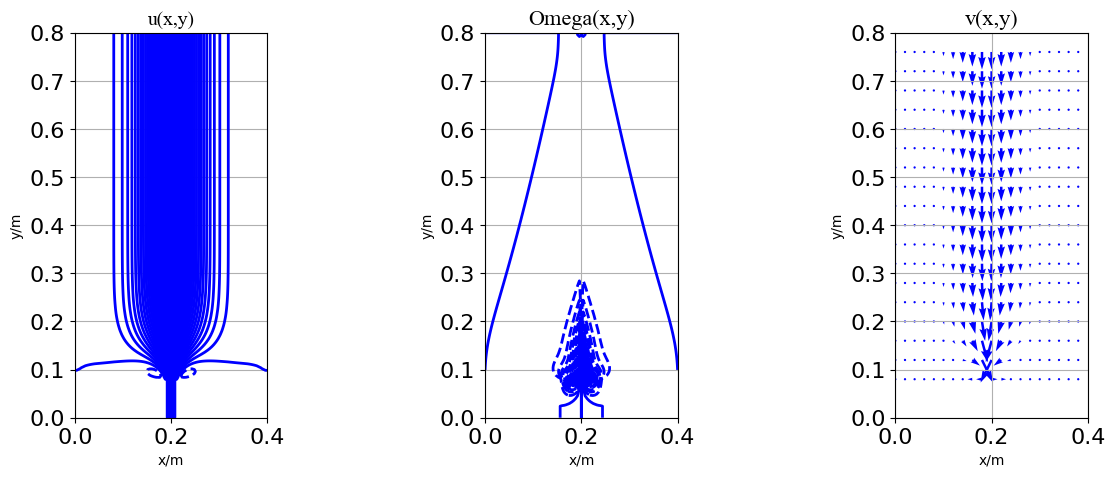

In [7]:
# u contour plot
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
CS1 = plt.contour(ValX, ValY, u2.T, 30, linewidths=2, colors='blue')
plt.grid(True)
plt.xlabel('x/m')
plt.ylabel('y/m')
plt.axis([0, 0.4, 0, 0.8])
plt.gca().set_aspect('equal', adjustable='box')
plt.title('u(x,y)', fontsize=14, fontname='Times New Roman', fontweight='normal')
plt.gca().tick_params(labelsize=16)

# Omega contour plot (vortex lines)
plt.subplot(1, 3, 2)
CS2 = plt.contour(ValX, ValY, Omega2.T, 100, linewidths=2, colors='blue')
plt.grid(True)
plt.xlabel('x/m')
plt.ylabel('y/m')
plt.axis([0, 0.4, 0, 0.8])
plt.gca().set_aspect('equal', adjustable='box')
plt.title('Omega(x,y)', fontsize=16, fontname='Times New Roman', fontweight='normal')
plt.gca().tick_params(labelsize=16)

# velocity vectors
plt.subplot(1, 3, 3)
plt.axis([0, 0.4, 0, 0.8])
plt.gca().set_aspect('equal', adjustable='box')
plt.grid(True)
q = plt.quiver(ValXt, ValYt, gYt2.T, -gXt2.T, linewidths=2, width=0.013, color ='blue')
plt.xlabel('x/m')
plt.ylabel('y/m')
plt.axis([0, 0.4, 0, 0.8])
plt.title('v(x,y)', fontsize=16, fontname='Times New Roman', fontweight='normal')
plt.gca().tick_params(labelsize=16)

plt.show()